# Huấn luyện VGG16 từ ZIP trên Google Drive rồi copy sang local Colab

Notebook này làm theo đúng flow:

- Mount Google Drive
- Copy **1 file ZIP** từ Drive sang `/content`
- Giải nén ZIP vào local của Colab
- Tự tìm đúng thư mục chứa `train/`, `val/`, `test`
- Dùng **VGG16**
- Ảnh resize về **128x128**
- `BATCH_SIZE = 32`
- Mỗi epoch có:
  - `accuracy`
  - `val_accuracy`
  - `loss`
  - `val_loss`
  - `learning_rate`
- Mỗi epoch sẽ lưu **model tốt nhất** theo `val_accuracy`
- Cuối cùng đánh giá trên:
  - tập **train**
  - tập **test**

## 1. Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Khai báo đường dẫn và tham số

Bạn chỉ cần sửa:
- `ZIP_PATH_IN_DRIVE`
- `OUTPUT_DIR`

In [25]:
import os

# ====== SỬA 2 DÒNG NÀY ======
ZIP_PATH_IN_DRIVE = "/content/drive/MyDrive/original_dataset.zip"
OUTPUT_DIR = "/content/drive/MyDrive/vgg16_zip_local_128_batch32_outputs_ORI"
# ============================

LOCAL_ZIP_PATH = "/content/original_dataset.zip"
LOCAL_EXTRACT_DIR = "/content/original_dataset_local"

IMG_SIZE = (128, 128)
BATCH_SIZE = 32
EPOCHS_HEAD = 15
EPOCHS_FINE_TUNE = 5
SEED = 42

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("ZIP_PATH_IN_DRIVE:", ZIP_PATH_IN_DRIVE)
print("LOCAL_ZIP_PATH   :", LOCAL_ZIP_PATH)
print("LOCAL_EXTRACT_DIR:", LOCAL_EXTRACT_DIR)
print("OUTPUT_DIR       :", OUTPUT_DIR)

ZIP_PATH_IN_DRIVE: /content/drive/MyDrive/original_dataset.zip
LOCAL_ZIP_PATH   : /content/original_dataset.zip
LOCAL_EXTRACT_DIR: /content/original_dataset_local
OUTPUT_DIR       : /content/drive/MyDrive/vgg16_zip_local_128_batch32_outputs_ORI


## 3. Copy ZIP sang local của Colab và giải nén

Đây là flow nhanh hơn nhiều so với đọc trực tiếp từ Google Drive.

In [26]:
assert os.path.exists(ZIP_PATH_IN_DRIVE), f"Không tìm thấy file ZIP: {ZIP_PATH_IN_DRIVE}"

if not os.path.exists(LOCAL_ZIP_PATH):
    print("Đang copy ZIP sang local của Colab ...")
    !cp "$ZIP_PATH_IN_DRIVE" "$LOCAL_ZIP_PATH"
    print("Copy ZIP xong.")
else:
    print("ZIP đã có sẵn ở local, bỏ qua bước copy.")

if not os.path.exists(LOCAL_EXTRACT_DIR):
    os.makedirs(LOCAL_EXTRACT_DIR, exist_ok=True)
    print("Đang giải nén ZIP ...")
    !unzip -q "$LOCAL_ZIP_PATH" -d "$LOCAL_EXTRACT_DIR"
    print("Giải nén xong.")
else:
    print("Đã có thư mục local extract, bỏ qua bước giải nén.")

Đang copy ZIP sang local của Colab ...
Copy ZIP xong.
Đang giải nén ZIP ...
Giải nén xong.


## 4. Tự tìm thư mục dataset có `train/`, `val/`, `test`

In [27]:
import os

def find_dataset_root(base_dir):
    for root, dirs, files in os.walk(base_dir):
        dir_names = set(dirs)
        if {"train", "val", "test"}.issubset(dir_names):
            return root
    return None

DATASET_DIR = find_dataset_root(LOCAL_EXTRACT_DIR)
assert DATASET_DIR is not None, "Không tìm thấy thư mục chứa train/val/test sau khi giải nén."

TRAIN_DIR = os.path.join(DATASET_DIR, "train")
VAL_DIR = os.path.join(DATASET_DIR, "val")
TEST_DIR = os.path.join(DATASET_DIR, "test")

print("DATASET_DIR:", DATASET_DIR)
print("TRAIN_DIR  :", TRAIN_DIR)
print("VAL_DIR    :", VAL_DIR)
print("TEST_DIR   :", TEST_DIR)

DATASET_DIR: /content/original_dataset_local
TRAIN_DIR  : /content/original_dataset_local/train
VAL_DIR    : /content/original_dataset_local/val
TEST_DIR   : /content/original_dataset_local/test


## 5. Import thư viện

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input

np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 6. Kiểm tra thư mục dữ liệu

In [29]:
assert os.path.exists(TRAIN_DIR), f"Không tìm thấy train: {TRAIN_DIR}"
assert os.path.exists(VAL_DIR), f"Không tìm thấy val: {VAL_DIR}"
assert os.path.exists(TEST_DIR), f"Không tìm thấy test: {TEST_DIR}"

print("Đã tìm thấy train / val / test")
print("\n10 class đầu tiên trong train:")
for i, name in enumerate(sorted(os.listdir(TRAIN_DIR))[:10], 1):
    print(f"{i}. {name}")

Đã tìm thấy train / val / test

10 class đầu tiên trong train:
1. ABBOTTS BOOBY
2. ABYSSINIAN GROUND HORNBILL
3. AFRICAN PIED HORNBILL
4. AFRICAN PYGMY GOOSE
5. ALPINE CHOUGH
6. AMERICAN AVOCET
7. AMERICAN BITTERN
8. AMERICAN DIPPER
9. AMERICAN PIPIT
10. AMERICAN WIGEON


## 7. Tạo dataset từ thư mục ảnh

In [30]:
train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds_raw = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds_raw.class_names
num_classes = len(class_names)

print("Số class:", num_classes)
print("10 class đầu tiên:", class_names[:10])

Found 20080 files belonging to 150 classes.
Found 4248 files belonging to 150 classes.
Found 4468 files belonging to 150 classes.
Số class: 150
10 class đầu tiên: ['ABBOTTS BOOBY', 'ABYSSINIAN GROUND HORNBILL', 'AFRICAN PIED HORNBILL', 'AFRICAN PYGMY GOOSE', 'ALPINE CHOUGH', 'AMERICAN AVOCET', 'AMERICAN BITTERN', 'AMERICAN DIPPER', 'AMERICAN PIPIT', 'AMERICAN WIGEON']


## 8. Tiền xử lý cho VGG16

In [31]:
def preprocess_batch(x, y):
    x = tf.cast(x, tf.float32)
    x = preprocess_input(x)
    return x, y

train_ds = train_ds_raw.map(preprocess_batch, num_parallel_calls=2).prefetch(1)
val_ds = val_ds_raw.map(preprocess_batch, num_parallel_calls=2).prefetch(1)
test_ds = test_ds_raw.map(preprocess_batch, num_parallel_calls=2).prefetch(1)

print("Số batch train:", tf.data.experimental.cardinality(train_ds).numpy())
print("Số batch val  :", tf.data.experimental.cardinality(val_ds).numpy())
print("Số batch test :", tf.data.experimental.cardinality(test_ds).numpy())

Số batch train: 628
Số batch val  : 133
Số batch test : 140


## 9. Xem thử một vài ảnh mẫu

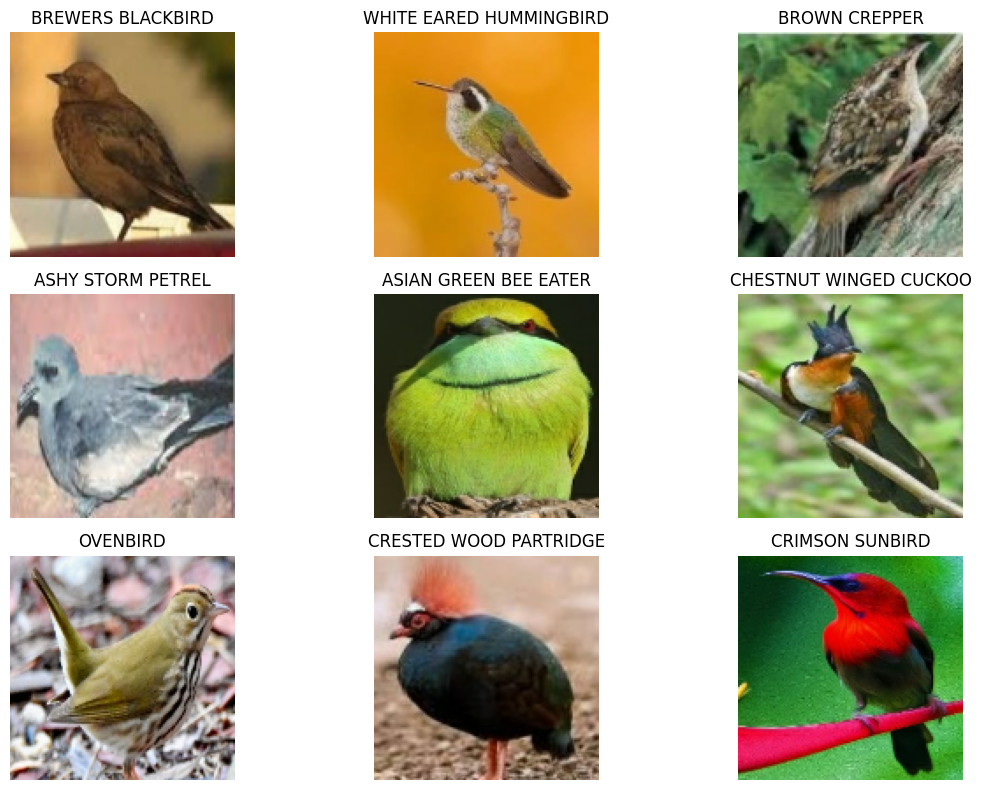

In [32]:
plt.figure(figsize=(12, 8))
for images, labels in train_ds_raw.take(1):
    for i in range(min(9, len(images))):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[int(labels[i])])
        plt.axis("off")
plt.tight_layout()
plt.show()

## 10. Xây dựng model VGG16

In [33]:
base_model = VGG16(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)
base_model.trainable = False

inputs = layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 150)            │        76,950 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,791,638 (56.43 MB)

 Trainable params: 76,950 (300.59 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

## 11. Callback lưu best model mỗi epoch và ghi learning rate

In [35]:
best_model_path = os.path.join(OUTPUT_DIR, "best_vgg16.keras")
final_model_path = os.path.join(OUTPUT_DIR, "final_vgg16.keras")
csv_log_path = os.path.join(OUTPUT_DIR, "training_log.csv")

class LrLogger(callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        lr = self.model.optimizer.learning_rate
        if isinstance(lr, tf.keras.optimizers.schedules.LearningRateSchedule):
            current_lr = float(tf.keras.backend.get_value(lr(self.model.optimizer.iterations)))
        else:
            current_lr = float(tf.keras.backend.get_value(lr))
        logs["learning_rate"] = current_lr
        print(f" - learning_rate: {current_lr:.8f}")

callback_list = [
    callbacks.ModelCheckpoint(
        filepath=best_model_path,
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1
    ),
    callbacks.CSVLogger(csv_log_path),
    callbacks.EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        verbose=1
    ),
    LrLogger()
]

print("Best model:", best_model_path)
print("Final model:", final_model_path)
print("CSV log:", csv_log_path)

Best model: /content/drive/MyDrive/vgg16_zip_local_128_batch32_outputs_ORI/best_vgg16.keras
Final model: /content/drive/MyDrive/vgg16_zip_local_128_batch32_outputs_ORI/final_vgg16.keras
CSV log: /content/drive/MyDrive/vgg16_zip_local_128_batch32_outputs_ORI/training_log.csv


## 12. Train phase 1

Khi chạy cell này, mỗi epoch sẽ hiện:
- accuracy
- loss
- val_accuracy
- val_loss
- learning_rate

In [36]:
history_phase1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_HEAD,
    callbacks=callback_list,
    verbose=1
)

Epoch 1/15
628/628 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.1496 - loss: 19.6290
Epoch 1: val_accuracy improved from None to 0.71045, saving model to /content/drive/MyDrive/vgg16_zip_local_128_batch32_outputs_ORI/best_vgg16.keras

Epoch 1: finished saving model to /content/drive/MyDrive/vgg16_zip_local_128_batch32_outputs_ORI/best_vgg16.keras
 - learning_rate: 0.00100000
628/628 ━━━━━━━━━━━━━━━━━━━━ 58s 88ms/step - accuracy: 0.3031 - loss: 11.8046 - val_accuracy: 0.7105 - val_loss: 2.2700 - learning_rate: 0.0010
Epoch 2/15
627/628 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.6065 - loss: 3.6743
Epoch 2: val_accuracy improved from 0.71045 to 0.78390, saving model to /content/drive/MyDrive/vgg16_zip_local_128_batch32_outputs_ORI/best_vgg16.keras

Epoch 2: finished saving model to /content/drive/MyDrive/vgg16_zip_local_128_batch32_outputs_ORI/best_vgg16.keras
 - learning_rate: 0.00100000
628/628 ━━━━━━━━━━━━━━━━━━━━ 77s 82ms/step - accuracy: 0.6370 - loss: 3.2950 - val_accuracy:

## 13. Fine-tune phase 2

Phase này mở một phần base model để tăng accuracy.

In [37]:
if EPOCHS_FINE_TUNE > 0:
    base_model.trainable = True

    fine_tune_at = int(len(base_model.layers) * 0.8)
    for layer in base_model.layers[:fine_tune_at]:
        layer.trainable = False

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    initial_epoch = len(history_phase1.history["loss"])
    total_epochs = initial_epoch + EPOCHS_FINE_TUNE

    history_phase2 = model.fit(
        train_ds,
        validation_data=val_ds,
        initial_epoch=initial_epoch,
        epochs=total_epochs,
        callbacks=callback_list,
        verbose=1
    )
else:
    history_phase2 = None
    print("Đã bỏ qua fine-tune phase 2.")

Epoch 16/20
628/628 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.8972 - loss: 0.4178
Epoch 16: val_accuracy improved from 0.86064 to 0.86182, saving model to /content/drive/MyDrive/vgg16_zip_local_128_batch32_outputs_ORI/best_vgg16.keras

Epoch 16: finished saving model to /content/drive/MyDrive/vgg16_zip_local_128_batch32_outputs_ORI/best_vgg16.keras
 - learning_rate: 0.00001000
628/628 ━━━━━━━━━━━━━━━━━━━━ 72s 107ms/step - accuracy: 0.9063 - loss: 0.3570 - val_accuracy: 0.8618 - val_loss: 0.8001 - learning_rate: 1.0000e-05
Epoch 17/20
627/628 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.9256 - loss: 0.2588
Epoch 17: val_accuracy improved from 0.86182 to 0.87241, saving model to /content/drive/MyDrive/vgg16_zip_local_128_batch32_outputs_ORI/best_vgg16.keras

Epoch 17: finished saving model to /content/drive/MyDrive/vgg16_zip_local_128_batch32_outputs_ORI/best_vgg16.keras
 - learning_rate: 0.00001000
628/628 ━━━━━━━━━━━━━━━━━━━━ 64s 102ms/step - accuracy: 0.9318 - loss: 0.2376 - 

## 14. Lưu model cuối cùng

In [38]:
model.save(final_model_path)
print("Đã lưu final model tại:", final_model_path)

Đã lưu final model tại: /content/drive/MyDrive/vgg16_zip_local_128_batch32_outputs_ORI/final_vgg16.keras


## 15. Gộp lịch sử train và vẽ biểu đồ

In [39]:
def combine_history(h1, h2=None):
    if h2 is None:
        return h1.history

    hist = {}
    keys = set(h1.history.keys()).union(set(h2.history.keys()))
    for k in keys:
        hist[k] = h1.history.get(k, []) + h2.history.get(k, [])
    return hist

full_history = combine_history(history_phase1, history_phase2)
history_df = pd.DataFrame(full_history)
display(history_df.head())

,val_accuracy,loss,learning_rate,accuracy,val_loss
0,0.710452,11.804626,0.0010,0.303137,2.269989
1,0.783898,3.294959,0.0010,0.637002,1.647370
2,0.810970,2.186023,0.0010,0.728287,1.413476
3,0.815913,1.723363,0.0010,0.767181,1.478734
4,0.810264,1.476948,0.0005,0.797410,1.556980


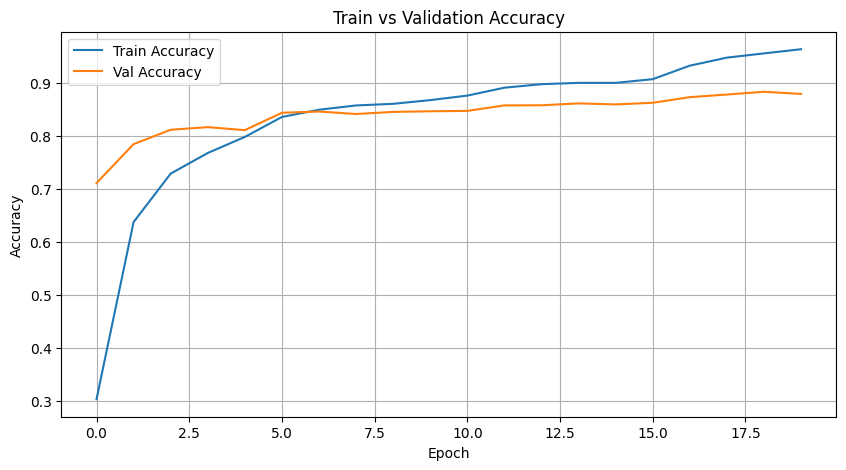

In [40]:
plt.figure(figsize=(10, 5))
plt.plot(full_history["accuracy"], label="Train Accuracy")
plt.plot(full_history["val_accuracy"], label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Train vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

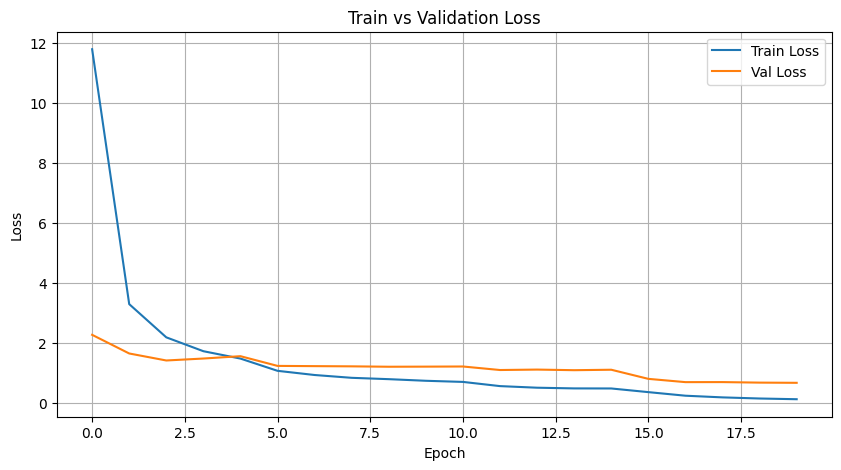

In [41]:
plt.figure(figsize=(10, 5))
plt.plot(full_history["loss"], label="Train Loss")
plt.plot(full_history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

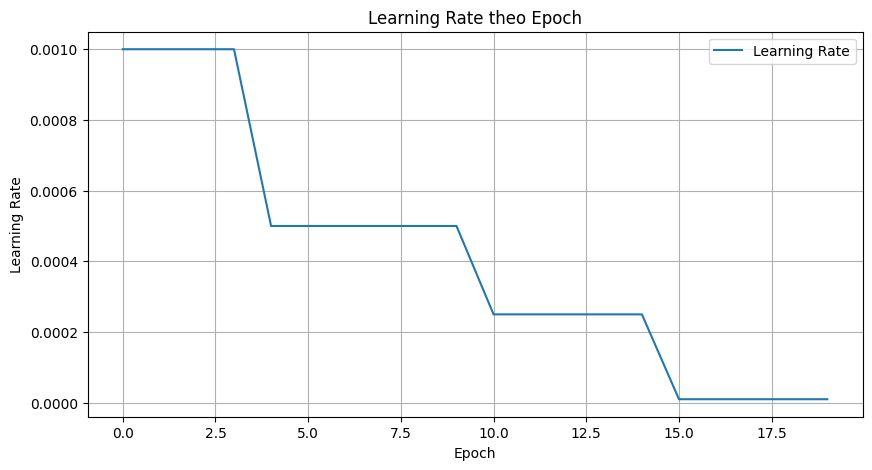

In [42]:
if "learning_rate" in full_history:
    plt.figure(figsize=(10, 5))
    plt.plot(full_history["learning_rate"], label="Learning Rate")
    plt.xlabel("Epoch")
    plt.ylabel("Learning Rate")
    plt.title("Learning Rate theo Epoch")
    plt.legend()
    plt.grid(True)
    plt.show()

In [43]:
plot_path = os.path.join(OUTPUT_DIR, "accuracy_loss_plot.png")

plt.figure(figsize=(10, 5))
plt.plot(full_history["accuracy"], label="Train Accuracy")
plt.plot(full_history["val_accuracy"], label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Train vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.savefig(plot_path, bbox_inches="tight")
plt.close()

print("Đã lưu biểu đồ tại:", plot_path)

Đã lưu biểu đồ tại: /content/drive/MyDrive/vgg16_zip_local_128_batch32_outputs_ORI/accuracy_loss_plot.png


## 16. Hàm đánh giá train và test

In [44]:
def collect_labels_and_predictions(model, dataset):
    y_true = []
    y_pred = []

    for batch_x, batch_y in dataset:
        preds = model.predict(batch_x, verbose=0)
        preds = np.argmax(preds, axis=1)

        y_true.extend(batch_y.numpy().tolist())
        y_pred.extend(preds.tolist())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return y_true, y_pred

def evaluate_dataset(model, dataset, split_name):
    y_true, y_pred = collect_labels_and_predictions(model, dataset)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
    rec = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)

    print(f"\n===== {split_name.upper()} =====")
    print(f"Accuracy        : {acc:.4f}")
    print(f"Precision macro : {prec:.4f}")
    print(f"Recall macro    : {rec:.4f}")
    print(f"F1 macro        : {f1:.4f}")

    return {
        "split": split_name,
        "accuracy": acc,
        "precision_macro": prec,
        "recall_macro": rec,
        "f1_macro": f1
    }, y_true, y_pred

## 17. Đánh giá trên train và test

In [45]:
train_metrics, y_train_true, y_train_pred = evaluate_dataset(model, train_ds, "train")
test_metrics, y_test_true, y_test_pred = evaluate_dataset(model, test_ds, "test")

metrics_df = pd.DataFrame([train_metrics, test_metrics])
display(metrics_df)


===== TRAIN =====
Accuracy        : 0.9985
Precision macro : 0.9985
Recall macro    : 0.9985
F1 macro        : 0.9985

===== TEST =====
Accuracy        : 0.8765
Precision macro : 0.8819
Recall macro    : 0.8773
F1 macro        : 0.8775


,split,accuracy,precision_macro,recall_macro,f1_macro
0,train,0.998506,0.998516,0.998526,0.998512
1,test,0.876455,0.881918,0.877331,0.877512


In [46]:
metrics_csv_path = os.path.join(OUTPUT_DIR, "metrics_summary.csv")
metrics_txt_path = os.path.join(OUTPUT_DIR, "metrics_summary.txt")

metrics_df.to_csv(metrics_csv_path, index=False)

with open(metrics_txt_path, "w", encoding="utf-8") as f:
    f.write("KET QUA DANH GIA MO HINH\n")
    f.write("=" * 50 + "\n")
    for row in [train_metrics, test_metrics]:
        f.write(f"Split: {row['split']}\n")
        f.write(f"Accuracy        : {row['accuracy']:.6f}\n")
        f.write(f"Precision macro : {row['precision_macro']:.6f}\n")
        f.write(f"Recall macro    : {row['recall_macro']:.6f}\n")
        f.write(f"F1 macro        : {row['f1_macro']:.6f}\n")
        f.write("-" * 50 + "\n")

print("Đã lưu metrics CSV:", metrics_csv_path)
print("Đã lưu metrics TXT:", metrics_txt_path)

Đã lưu metrics CSV: /content/drive/MyDrive/vgg16_zip_local_128_batch32_outputs_ORI/metrics_summary.csv
Đã lưu metrics TXT: /content/drive/MyDrive/vgg16_zip_local_128_batch32_outputs_ORI/metrics_summary.txt


## 18. Classification report trên tập test

In [47]:
report = classification_report(
    y_test_true,
    y_test_pred,
    target_names=class_names,
    zero_division=0
)

print(report)

report_path = os.path.join(OUTPUT_DIR, "classification_report_test.txt")
with open(report_path, "w", encoding="utf-8") as f:
    f.write(report)

print("Đã lưu classification report tại:", report_path)

                               precision    recall  f1-score   support

                ABBOTTS BOOBY       0.67      0.62      0.64        29
   ABYSSINIAN GROUND HORNBILL       0.93      0.90      0.91        29
        AFRICAN PIED HORNBILL       0.93      0.93      0.93        30
          AFRICAN PYGMY GOOSE       0.93      0.93      0.93        29
                ALPINE CHOUGH       0.83      0.89      0.86        27
              AMERICAN AVOCET       0.96      0.93      0.95        29
             AMERICAN BITTERN       0.93      0.93      0.93        27
              AMERICAN DIPPER       0.93      0.93      0.93        30
               AMERICAN PIPIT       0.93      0.90      0.91        29
              AMERICAN WIGEON       0.80      0.93      0.86        30
            ASHY STORM PETREL       0.78      0.70      0.74        30
        ASIAN GREEN BEE EATER       0.94      1.00      0.97        33
         ASIAN OPENBILL STORK       0.80      0.93      0.86        30
     

## 19. Hiển thị một vài ảnh dự đoán đúng và sai

Một vài ảnh dự đoán đúng:


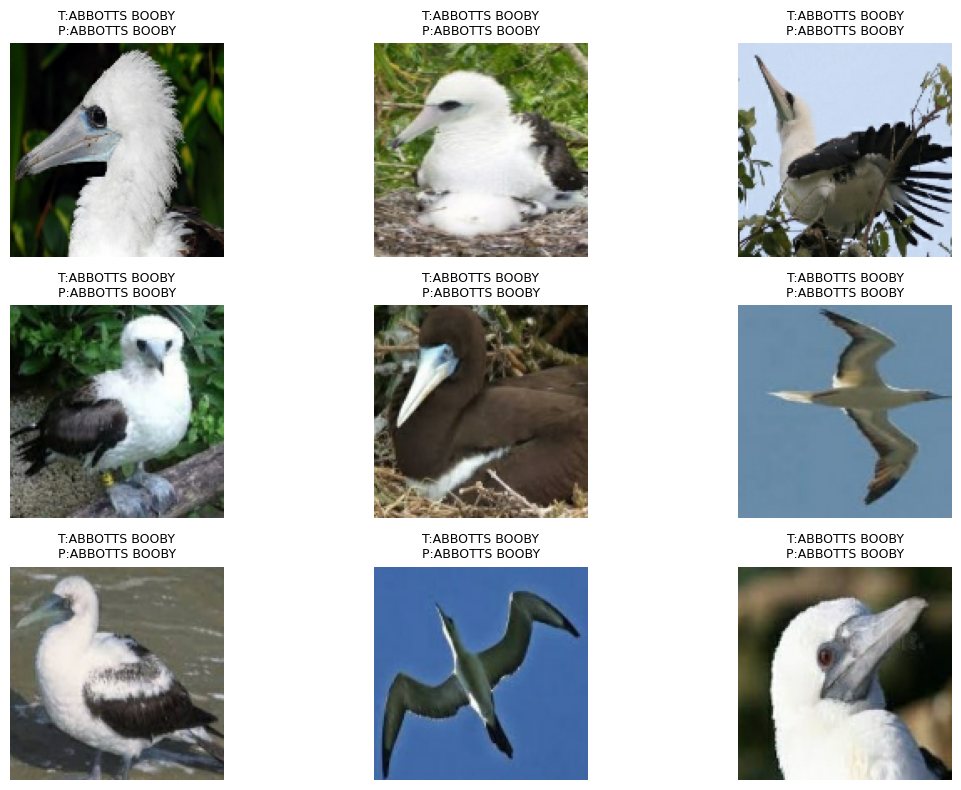

Một vài ảnh dự đoán sai:


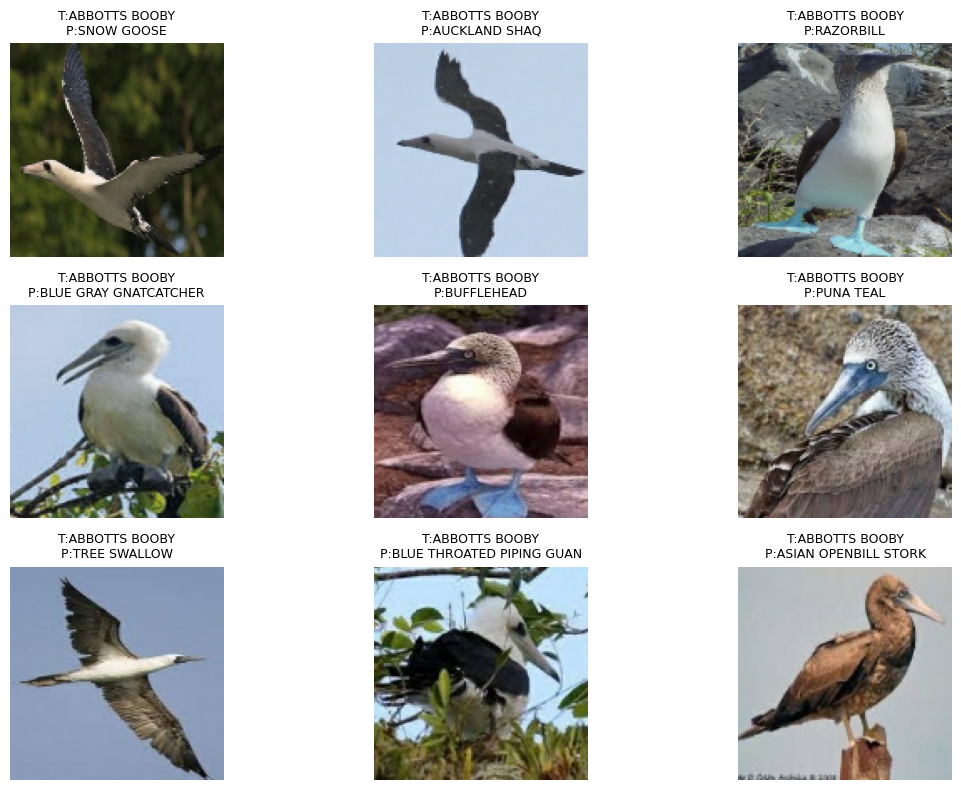

In [48]:
def show_predictions_from_raw_dataset(raw_dataset, y_pred, class_names, correct=True, max_images=9):
    images_all = []
    labels_all = []

    for images, labels in raw_dataset:
        images_all.append(images.numpy().astype("uint8"))
        labels_all.append(labels.numpy())

    X = np.concatenate(images_all, axis=0)
    y_true = np.concatenate(labels_all, axis=0)

    indices = np.where(y_true == y_pred)[0] if correct else np.where(y_true != y_pred)[0]
    if len(indices) == 0:
        print("Không có ảnh phù hợp để hiển thị.")
        return

    chosen = indices[:max_images]

    plt.figure(figsize=(12, 8))
    for i, idx in enumerate(chosen):
        plt.subplot(3, 3, i + 1)
        plt.imshow(X[idx])
        plt.title(f"T:{class_names[y_true[idx]]}\nP:{class_names[y_pred[idx]]}", fontsize=9)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

print("Một vài ảnh dự đoán đúng:")
show_predictions_from_raw_dataset(test_ds_raw, y_test_pred, class_names, correct=True, max_images=9)

print("Một vài ảnh dự đoán sai:")
show_predictions_from_raw_dataset(test_ds_raw, y_test_pred, class_names, correct=False, max_images=9)

## 20. Load lại model tốt nhất nếu cần

In [ ]:
best_loaded_model = tf.keras.models.load_model(best_model_path)
print("Đã load best model từ:", best_model_path)

## 21. Tóm tắt đầu ra đã lưu

Sau khi chạy xong notebook, trong `OUTPUT_DIR` sẽ có:
- `best_vgg16.keras`
- `final_vgg16.keras`
- `training_log.csv`
- `accuracy_loss_plot.png`
- `metrics_summary.csv`
- `metrics_summary.txt`
- `classification_report_test.txt`